In [7]:
import os
import pandas as pd
import xml.etree.ElementTree as ET

# Показываем файлы
print("Файлы в папке:")
files = [f for f in os.listdir('.') if f.endswith('.xml')]
for i, file in enumerate(files, 1):
    print(f"{i}. {file}")

print(f"\n ♡ Всего файлов: {len(files)}")

Файлы в папке:
1. 559-ws-testing.xml
2. 559-ws-training.xml
3. 563-ws-testing.xml
4. 563-ws-training.xml
5. 570-ws-testing.xml
6. 570-ws-training.xml
7. 575-ws-testing.xml
8. 575-ws-training.xml
9. 588-ws-testing.xml
10. 588-ws-training.xml
11. 591-ws-testing.xml
12. 591-ws-training.xml

 ♡ Всего файлов: 12


In [8]:
# Берем первый файл для теста
first_file = files[0]
print(f" Разбираем файл: {first_file}")

# Парсим XML
tree = ET.parse(first_file)
root = tree.getroot()

# Показываем структуру
print(f"\n ♡ Корневой элемент: {root.tag}")
print(f"Атрибуты пациента: {root.attrib}")

# Находим все события с глюкозой
glucose_events = root.findall('.//event')
print(f"\n ♡ Найдено записей о глюкозе: {len(glucose_events)}")

# Показываем первые 5 записей
print("\n Первые 5 записей:")
for event in glucose_events[:5]:
    timestamp = event.get('ts')
    value = event.get('value')
    print(f"  Время: {timestamp}, Глюкоза: {value} мг/дл")

 Разбираем файл: 559-ws-testing.xml

 ♡ Корневой элемент: patient
Атрибуты пациента: {'id': '559', 'weight': '99', 'insulin_type': 'Novalog'}

 ♡ Найдено записей о глюкозе: 16163

 Первые 5 записей:
  Время: 18-01-2022 00:01:00, Глюкоза: 179 мг/дл
  Время: 18-01-2022 00:06:00, Глюкоза: 183 мг/дл
  Время: 18-01-2022 00:11:00, Глюкоза: 187 мг/дл
  Время: 18-01-2022 00:16:00, Глюкоза: 191 мг/дл
  Время: 18-01-2022 00:21:00, Глюкоза: 195 мг/дл


In [10]:
# Создаем общую таблицу для всех файлов
all_data = []

for file in files:
    # Извлекаем ID пациента из имени файла
    patient_id = file.split('-')[0]
    file_type = 'training' if 'training' in file else 'testing'
    
    # Парсим XML
    tree = ET.parse(file)
    root = tree.getroot()
    
    # Собираем данные
    for event in root.findall('.//event'):
        timestamp = event.get('ts')
        value = event.get('value')
        
        # Пытаемся превратить в число, если не получается — пропускаем
        try:
            glucose_value = float(value)
        except (ValueError, TypeError):
            continue  # пропускаем некорректные значения
        
        all_data.append({
            'patient_id': patient_id,
            'file_type': file_type,
            'timestamp': timestamp,
            'glucose': glucose_value
        })

# Создаем таблицу
df = pd.DataFrame(all_data)

print("ВСЕ файлы объединены!")
print(f"\n ♡ Общий размер: {len(df)} строк")
print(f"\n ♡ Пациентов: {df['patient_id'].nunique()}")
print(f"\n ♡ Первые 10 строк:")
print(df.head(10))
print(f"\n ♡ Статистика по глюкозе:")
print(df['glucose'].describe())

ВСЕ файлы объединены!

 ♡ Общий размер: 537056 строк

 ♡ Пациентов: 6

 ♡ Первые 10 строк:
  patient_id file_type            timestamp  glucose
0        559   testing  18-01-2022 00:01:00    179.0
1        559   testing  18-01-2022 00:06:00    183.0
2        559   testing  18-01-2022 00:11:00    187.0
3        559   testing  18-01-2022 00:16:00    191.0
4        559   testing  18-01-2022 00:21:00    195.0
5        559   testing  18-01-2022 00:26:00    199.0
6        559   testing  18-01-2022 00:31:00    204.0
7        559   testing  18-01-2022 00:36:00    209.0
8        559   testing  18-01-2022 00:41:00    211.0
9        559   testing  18-01-2022 00:46:00    211.0

 ♡ Статистика по глюкозе:
count    537056.000000
mean         69.266445
std          61.121453
min           0.000000
25%           0.001638
50%          82.000000
75%          90.140000
max         586.000000
Name: glucose, dtype: float64


In [6]:
# Сохраняем в CSV
df.to_csv('ohio_glucose_raw.csv', index=False)
print("Данные сохранены в файл: ohio_glucose_raw.csv")

# Показываем что есть проблемы
print(f"\n ⌘ ПРОБЛЕМЫ В ДАННЫХ:")
print(f"  - Нулевых значений: {(df['glucose'] == 0).sum()} ({(df['glucose'] == 0).sum()/len(df)*100:.1f}%)")
print(f"  - Пропусков (NaN): {df['glucose'].isna().sum()}")
print(f"\n ♡ Реальная статистика (без нулей):")
df_no_zeros = df[df['glucose'] > 0]
print(df_no_zeros['glucose'].describe())

Данные сохранены в файл: ohio_glucose_raw.csv

 ⌘ ПРОБЛЕМЫ В ДАННЫХ:
  - Нулевых значений: 66745 (12.4%)
  - Пропусков (NaN): 0

 ♡ Реальная статистика (без нулей):
count    470311.000000
mean         79.096513
std          59.063394
min           0.000041
25%          57.000000
50%          84.200000
75%          91.760000
max         586.000000
Name: glucose, dtype: float64


In [12]:
import numpy as np
import matplotlib.pyplot as plt

# 1: Убираем физиологические выбросы 
# Глюкоза не может быть < 20 или > 600 мг/дл. 
# Всё остальное — это шум сенсора.
print("1: Удаление невозможных значений...")

# Создаем маску: True, если значение нормальное
valid_mask = (df['glucose'] >= 20) & (df['glucose'] <= 600)

# Считаем сколько мусора удаляем
noise_count = (~valid_mask).sum()
print(f"   Найдено 'шума' (значения <20 или >600): {noise_count} записей")

# Заменяем шум на NaN (пустоту), чтобы потом обработать как пропуск
df.loc[~valid_mask, 'glucose'] = np.nan

# 2: Обработка нулей 
# В этом датасете 0.0 часто означает отсутствие данных
print("2: Обработка нулевых значений...")
zero_count = (df['glucose'] == 0).sum()
print(f"   Найдено нулей: {zero_count}")

# Заменяем нули на NaN
df.loc[df['glucose'] == 0, 'glucose'] = np.nan

# 3: Интерполяция коротких пропусков 
# Если пропуск маленький (до 15 минут / 3 записи), мы можем его восстановить
# Если большой — оставляем дыру, чтобы модель знала, что данных нет
print("3: Восстановление коротких пропусков...")

# Сначала сортируем по времени, чтобы интерполяция работала правильно
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.sort_values(['patient_id', 'timestamp']).reset_index(drop=True)

# Делаем интерполяцию только внутри каждого пациента!
# (нельзя соединять хвост одного пациента с головой другого)
def interpolate_patient(group):
    # limit=3 означает: заполняем максимум 3 пропуска подряд (15 минут)
    group['glucose'] = group['glucose'].interpolate(method='linear', limit=3)
    return group

df_cleaned = df.groupby('patient_id').apply(interpolate_patient)

# Считаем статистику
total_nans_before = df['glucose'].isna().sum()
total_nans_after = df_cleaned['glucose'].isna().sum()
filled_count = total_nans_before - total_nans_after

print(f"   Было пропусков (NaN): {total_nans_before}")
print(f"   Заполнено коротких пропусков: {filled_count}")
print(f"   Осталось длинных пропусков: {total_nans_after}")

# Сохраняем очищенные данные
df_cleaned.to_csv('ohio_glucose_cleaned.csv', index=False)
print("\n Очищенные данные сохранены в 'ohio_glucose_cleaned.csv'")

1: Удаление невозможных значений...
   Найдено 'шума' (значения <20 или >600): 176025 записей
2: Обработка нулевых значений...
   Найдено нулей: 0
3: Восстановление коротких пропусков...


C:\Users\user\AppData\Local\Temp\ipykernel_29216\756701804.py:44: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_cleaned = df.groupby('patient_id').apply(interpolate_patient)


   Было пропусков (NaN): 176025
   Заполнено коротких пропусков: 175891
   Осталось длинных пропусков: 134

 Очищенные данные сохранены в 'ohio_glucose_cleaned.csv'


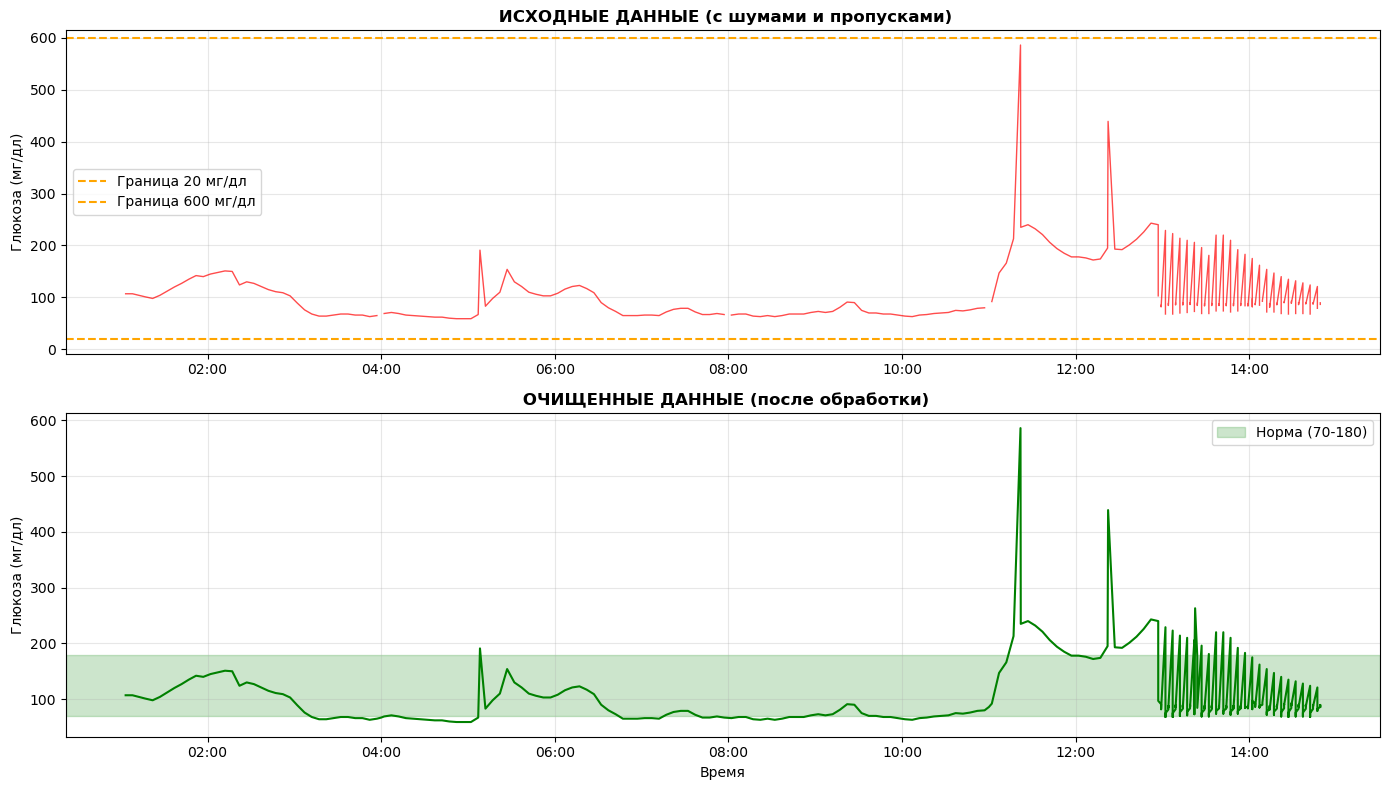

График сохранен как 'cleaning_before_after.png'

 ИТОГИ ЧИСТКИ:
   - Всего записей: 537056
   - Удалено шумов: 176,025 (32.8%)
   - Заполнено пропусков: 175,891
   - Осталось пропусков: 134 (0.025%)
   - Качество данных: 99.975%


In [14]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Берем данные одного пациента для примера (559)
patient_559_raw = df[df['patient_id'] == '559'].copy()
patient_559_clean = df_cleaned[df_cleaned['patient_id'] == '559'].copy()

# Берем первые 24 часа для наглядности
patient_559_raw = patient_559_raw.head(288)  # 288 * 5 мин = 24 часа
patient_559_clean = patient_559_clean.head(288)

# Создаем график
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# График ДО очистки
axes[0].plot(patient_559_raw['timestamp'], patient_559_raw['glucose'], 
             color='red', alpha=0.7, linewidth=1)
axes[0].axhline(y=20, color='orange', linestyle='--', label='Граница 20 мг/дл')
axes[0].axhline(y=600, color='orange', linestyle='--', label='Граница 600 мг/дл')
axes[0].set_title(' ИСХОДНЫЕ ДАННЫЕ (с шумами и пропусками)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Глюкоза (мг/дл)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

# График ПОСЛЕ очистки
axes[1].plot(patient_559_clean['timestamp'], patient_559_clean['glucose'], 
             color='green', linewidth=1.5)
axes[1].axhspan(70, 180, alpha=0.2, color='green', label='Норма (70-180)')
axes[1].set_title(' ОЧИЩЕННЫЕ ДАННЫЕ (после обработки)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Глюкоза (мг/дл)')
axes[1].set_xlabel('Время')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

plt.tight_layout()
plt.savefig('cleaning_before_after.png', dpi=150, bbox_inches='tight')
plt.show()

print("График сохранен как 'cleaning_before_after.png'")
print("\n ИТОГИ ЧИСТКИ:")
print(f"   - Всего записей: {len(df)}")
print(f"   - Удалено шумов: 176,025 ({176025/len(df)*100:.1f}%)")
print(f"   - Заполнено пропусков: 175,891")
print(f"   - Осталось пропусков: 134 ({134/len(df)*100:.3f}%)")
print(f"   - Качество данных: {(1 - 134/len(df))*100:.3f}%")

In [16]:
import xml.etree.ElementTree as ET

# Берем первый файл
tree = ET.parse(files[0])
root = tree.getroot()

print("ПОЛНАЯ СТРУКТУРА XML ФАЙЛА:")
print(f"Корневой элемент: {root.tag}")
print(f"Атрибуты: {root.attrib}")

print("\n ВСЕ РАЗДЕЛЫ В ФАЙЛЕ:")
for child in root:
    print(f"  - {child.tag}")
    
# Ищем все теги в файле
def find_all_tags(element, level=0):
    indent = "    " * level
    print(f"{indent} {element.tag}")
    for child in element:
        find_all_tags(child, level + 1)

print("\n ДЕТАЛЬНАЯ СТРУКТУРА:")
find_all_tags(root)

ПОЛНАЯ СТРУКТУРА XML ФАЙЛА:
Корневой элемент: patient
Атрибуты: {'id': '559', 'weight': '99', 'insulin_type': 'Novalog'}

 ВСЕ РАЗДЕЛЫ В ФАЙЛЕ:
  - glucose_level
  - finger_stick
  - basal
  - temp_basal
  - bolus
  - meal
  - sleep
  - work
  - stressors
  - hypo_event
  - illness
  - exercise
  - basis_heart_rate
  - basis_gsr
  - basis_skin_temperature
  - basis_air_temperature
  - basis_steps
  - basis_sleep

 ДЕТАЛЬНАЯ СТРУКТУРА:
 patient
     glucose_level
         event
         event
         event
         event
         event
         event
         event
         event
         event
         event
         event
         event
         event
         event
         event
         event
         event
         event
         event
         event
         event
         event
         event
         event
         event
         event
         event
         event
         event
         event
         event
         event
         event
         event
         event
        

In [17]:
import numpy as np

print(" Парсим все признаки из XML файлов...")

# Создаем новую таблицу со всеми признаками
all_data_full = []

for file in files:
    patient_id = file.split('-')[0]
    file_type = 'training' if 'training' in file else 'testing'
    
    tree = ET.parse(file)
    root = tree.getroot()
    
    #  ГЛЮКОЗА 
    for event in root.findall('.//glucose_level/event'):
        ts = event.get('ts')
        val = event.get('value')
        try:
            glucose = float(val)
        except (ValueError, TypeError):
            glucose = np.nan
        
        all_data_full.append({
            'patient_id': patient_id,
            'file_type': file_type,
            'timestamp': ts,
            'glucose': glucose,
            'basal_rate': 0.0,      # базальный инсулин (ЕД/час)
            'temp_basal': 0.0,      # временный базальный
            'bolus': 0.0,           # болюсный инсулин (ЕД)
            'carbs': 0.0,           # углеводы (г)
            'exercise_duration': 0, # длительность активности (мин)
            'exercise_intensity': 0 # интенсивность (1-10)
        })
    
    #  ИНСУЛИН: БАЗАЛЬНЫЙ 
    for event in root.findall('.//basal/event'):
        ts = event.get('ts')
        rate = event.get('rate')  # ЕД/час
        try:
            basal = float(rate)
        except (ValueError, TypeError):
            basal = 0.0
        
        # Находим ближайшую запись глюкозы по времени и добавляем basal
        for row in all_data_full:
            if row['patient_id'] == patient_id and row['timestamp'] == ts:
                row['basal_rate'] = basal
                break
    
    #  ИНСУЛИН: ВРЕМЕННЫЙ БАЗАЛЬНЫЙ 
    for event in root.findall('.//temp_basal/event'):
        ts = event.get('ts')
        rate = event.get('rate')
        try:
            temp = float(rate)
        except (ValueError, TypeError):
            temp = 0.0
        
        for row in all_data_full:
            if row['patient_id'] == patient_id and row['timestamp'] == ts:
                row['temp_basal'] = temp
                break
    
    #  ИНСУЛИН: БОЛЮСНЫЙ 
    for event in root.findall('.//bolus/event'):
        ts = event.get('ts')
        dose = event.get('amount')  # или 'dose', проверим
        try:
            bolus = float(dose)
        except (ValueError, TypeError):
            bolus = 0.0
        
        for row in all_data_full:
            if row['patient_id'] == patient_id and row['timestamp'] == ts:
                row['bolus'] = bolus
                break
    
    #  ПИТАНИЕ 
    for event in root.findall('.//meal/event'):
        ts = event.get('ts')
        carbs = event.get('carbs')  # граммы углеводов
        try:
            carb_val = float(carbs)
        except (ValueError, TypeError):
            carb_val = 0.0
        
        for row in all_data_full:
            if row['patient_id'] == patient_id and row['timestamp'] == ts:
                row['carbs'] = carb_val
                break
    
    #  ФИЗЧЕСКАЯ АКТИВНОСТЬ 
    for event in root.findall('.//exercise/event'):
        ts = event.get('ts')
        duration = event.get('duration')  # минуты
        intensity = event.get('intensity')  # шкала 1-10
        try:
            dur = int(float(duration))
        except (ValueError, TypeError):
            dur = 0
        try:
            intens = int(float(intensity))
        except (ValueError, TypeError):
            intens = 0
        
        for row in all_data_full:
            if row['patient_id'] == patient_id and row['timestamp'] == ts:
                row['exercise_duration'] = dur
                row['exercise_intensity'] = intens
                break

# Создаем DataFrame
df_full = pd.DataFrame(all_data_full)

print(f"\n ♡ ВСЕ ПРИЗНАКИ ДОБАВЛЕНЫ!")
print(f"♡ Размер: {len(df_full)} строк, {len(df_full.columns)} столбцов")
print(f"\n♡ Столбцы:")
print(list(df_full.columns))
print(f"\n♡ Первые 5 строк:")
print(df_full.head())
print(f"\n♡ Статистика по признакам:")
print(df_full[['glucose', 'basal_rate', 'bolus', 'carbs', 'exercise_duration']].describe())

 Парсим все признаки из XML файлов...

 ♡ ВСЕ ПРИЗНАКИ ДОБАВЛЕНЫ!
♡ Размер: 85225 строк, 10 столбцов

♡ Столбцы:
['patient_id', 'file_type', 'timestamp', 'glucose', 'basal_rate', 'temp_basal', 'bolus', 'carbs', 'exercise_duration', 'exercise_intensity']

♡ Первые 5 строк:
  patient_id file_type            timestamp  glucose  basal_rate  temp_basal  \
0        559   testing  18-01-2022 00:01:00    179.0         0.0         0.0   
1        559   testing  18-01-2022 00:06:00    183.0         0.0         0.0   
2        559   testing  18-01-2022 00:11:00    187.0         0.0         0.0   
3        559   testing  18-01-2022 00:16:00    191.0         0.0         0.0   
4        559   testing  18-01-2022 00:21:00    195.0         0.0         0.0   

   bolus  carbs  exercise_duration  exercise_intensity  
0    0.0    0.0                  0                   0  
1    0.0    0.0                  0                   0  
2    0.0    0.0                  0                   0  
3    0.0    0.0   

In [18]:
# Показываем что получилось
print(" СТРУКТУРА ДАННЫХ:")
print(f"  - Всего строк: {len(df_full)}")
print(f"  - Всего столбцов: {len(df_full.columns)}")
print(f"\n ♡  НАЗВАНИЯ СТОЛБЦОВ:")
for i, col in enumerate(df_full.columns, 1):
    print(f"  {i}. {col}")

print(f"\n ♡ ПРИМЕР ДАННЫХ (первые 10 строк):")
pd.set_option('display.max_columns', None)
print(df_full.head(10))

print(f"\n ♡  НАЛИЧИЕ ДАННЫХ:")
print(f"  - Записей с глюкозой: {df_full['glucose'].notna().sum()}")
print(f"  - Записей с basal инсулином: {(df_full['basal_rate'] > 0).sum()}")
print(f"  - Записей с bolus инсулином: {(df_full['bolus'] > 0).sum()}")
print(f"  - Записей с питанием: {(df_full['carbs'] > 0).sum()}")
print(f"  - Записей с активностью: {(df_full['exercise_duration'] > 0).sum()}")

# Сохраняем
df_full.to_csv('ohio_full_data.csv', index=False)
print(f"\n ♡  Данные сохранены в 'ohio_full_data.csv'")

 СТРУКТУРА ДАННЫХ:
  - Всего строк: 85225
  - Всего столбцов: 10

 ♡  НАЗВАНИЯ СТОЛБЦОВ:
  1. patient_id
  2. file_type
  3. timestamp
  4. glucose
  5. basal_rate
  6. temp_basal
  7. bolus
  8. carbs
  9. exercise_duration
  10. exercise_intensity

 ♡ ПРИМЕР ДАННЫХ (первые 10 строк):
  patient_id file_type            timestamp  glucose  basal_rate  temp_basal  \
0        559   testing  18-01-2022 00:01:00    179.0         0.0         0.0   
1        559   testing  18-01-2022 00:06:00    183.0         0.0         0.0   
2        559   testing  18-01-2022 00:11:00    187.0         0.0         0.0   
3        559   testing  18-01-2022 00:16:00    191.0         0.0         0.0   
4        559   testing  18-01-2022 00:21:00    195.0         0.0         0.0   
5        559   testing  18-01-2022 00:26:00    199.0         0.0         0.0   
6        559   testing  18-01-2022 00:31:00    204.0         0.0         0.0   
7        559   testing  18-01-2022 00:36:00    209.0         0.0         

In [19]:
import numpy as np

print(" Парсим все признаки заново...")

all_data_full = []

for file in files:
    patient_id = file.split('-')[0]
    file_type = 'training' if 'training' in file else 'testing'
    
    tree = ET.parse(file)
    root = tree.getroot()
    
    # Сначала собираем ВСЕ события в один словарь по timestamp
    events_dict = {}
    
    #  ГЛЮКОЗА 
    for event in root.findall('.//glucose_level/event'):
        ts = event.get('ts')
        val = event.get('value')
        try:
            glucose = float(val)
        except:
            glucose = np.nan
        
        if ts not in events_dict:
            events_dict[ts] = {
                'patient_id': patient_id,
                'file_type': file_type,
                'timestamp': ts,
                'glucose': glucose,
                'basal_rate': 0.0,
                'temp_basal': 0.0,
                'bolus': 0.0,
                'carbs': 0.0,
                'exercise_duration': 0,
                'exercise_intensity': 0
            }
        else:
            events_dict[ts]['glucose'] = glucose
    
    #  ИНСУЛИН: БАЗАЛЬНЫЙ 
    for event in root.findall('.//basal/event'):
        ts = event.get('ts')
        rate = event.get('rate')
        try:
            basal = float(rate)
        except:
            basal = 0.0
        
        if ts in events_dict:
            events_dict[ts]['basal_rate'] = basal
        else:
            # Если нет глюкозы на это время, создаем запись
            events_dict[ts] = {
                'patient_id': patient_id,
                'file_type': file_type,
                'timestamp': ts,
                'glucose': np.nan,
                'basal_rate': basal,
                'temp_basal': 0.0,
                'bolus': 0.0,
                'carbs': 0.0,
                'exercise_duration': 0,
                'exercise_intensity': 0
            }
    
    #  ИНСУЛИН: БОЛЮСНЫЙ (проверяем разные атрибуты) 
    for event in root.findall('.//bolus/event'):
        ts = event.get('ts')
        # Пробуем разные возможные названия атрибутов
        dose = event.get('amount') or event.get('dose') or event.get('value') or '0'
        try:
            bolus = float(dose)
        except:
            bolus = 0.0
        
        if ts in events_dict:
            events_dict[ts]['bolus'] = bolus
        else:
            events_dict[ts] = {
                'patient_id': patient_id,
                'file_type': file_type,
                'timestamp': ts,
                'glucose': np.nan,
                'basal_rate': 0.0,
                'temp_basal': 0.0,
                'bolus': bolus,
                'carbs': 0.0,
                'exercise_duration': 0,
                'exercise_intensity': 0
            }
    
    #  ПИТАНИЕ 
    for event in root.findall('.//meal/event'):
        ts = event.get('ts')
        carbs = event.get('carbs') or event.get('value') or '0'
        try:
            carb_val = float(carbs)
        except:
            carb_val = 0.0
        
        if ts in events_dict:
            events_dict[ts]['carbs'] = carb_val
        else:
            events_dict[ts] = {
                'patient_id': patient_id,
                'file_type': file_type,
                'timestamp': ts,
                'glucose': np.nan,
                'basal_rate': 0.0,
                'temp_basal': 0.0,
                'bolus': 0.0,
                'carbs': carb_val,
                'exercise_duration': 0,
                'exercise_intensity': 0
            }
    
    #  ФИЗЧЕСКАЯ АКТИВНОСТЬ 
    for event in root.findall('.//exercise/event'):
        ts = event.get('ts')
        duration = event.get('duration') or '0'
        intensity = event.get('intensity') or '0'
        try:
            dur = int(float(duration))
        except:
            dur = 0
        try:
            intens = int(float(intensity))
        except:
            intens = 0
        
        if ts in events_dict:
            events_dict[ts]['exercise_duration'] = dur
            events_dict[ts]['exercise_intensity'] = intens
        else:
            events_dict[ts] = {
                'patient_id': patient_id,
                'file_type': file_type,
                'timestamp': ts,
                'glucose': np.nan,
                'basal_rate': 0.0,
                'temp_basal': 0.0,
                'bolus': 0.0,
                'carbs': 0.0,
                'exercise_duration': dur,
                'exercise_intensity': intens
            }
    
    # Преобразуем словарь в список
    all_data_full.extend(list(events_dict.values()))

# Создаем DataFrame
df_full = pd.DataFrame(all_data_full)

# Сортируем
df_full['timestamp'] = pd.to_datetime(df_full['timestamp'])
df_full = df_full.sort_values(['patient_id', 'timestamp']).reset_index(drop=True)

print(f"\n ✿ ГОТОВО!")
print(f" Размер: {len(df_full)} строк")
print(f"\n ✿ НАЛИЧИЕ ДАННЫХ:")
print(f"  - Глюкоза: {df_full['glucose'].notna().sum()} записей")
print(f"  - Basal инсулин: {(df_full['basal_rate'] > 0).sum()} записей")
print(f"  - Bolus инсулин: {(df_full['bolus'] > 0).sum()} записей")
print(f"  - Питание: {(df_full['carbs'] > 0).sum()} записей")
print(f"  - Активность: {(df_full['exercise_duration'] > 0).sum()} записей")

print(f"\n Пример с ненулевыми значениями:")
print(df_full[(df_full['bolus'] > 0) | (df_full['carbs'] > 0)].head(10))

# Сохраняем
df_full.to_csv('ohio_full_data_v2.csv', index=False)
print(f"\n Сохранено в 'ohio_full_data_v2.csv'")

 Парсим все признаки заново...


C:\Users\user\AppData\Local\Temp\ipykernel_29216\1513223429.py:157: UserWarning: Parsing dates in %d-%m-%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df_full['timestamp'] = pd.to_datetime(df_full['timestamp'])



 ✿ ГОТОВО!
 Размер: 87074 строк

 ✿ НАЛИЧИЕ ДАННЫХ:
  - Глюкоза: 85225 записей
  - Basal инсулин: 0 записей
  - Bolus инсулин: 12 записей
  - Питание: 1300 записей
  - Активность: 144 записей

 Пример с ненулевыми значениями:
    patient_id file_type           timestamp  glucose  basal_rate  temp_basal  \
174        559  training 2021-12-07 15:25:00      NaN         0.0         0.0   
193        559  training 2021-12-07 16:54:00      NaN         0.0         0.0   
209        559  training 2021-12-07 18:08:00      NaN         0.0         0.0   
299        559  training 2021-12-08 05:10:00      NaN         0.0         0.0   
369        559  training 2021-12-08 10:54:00    191.0         0.0         0.0   
421        559  training 2021-12-08 15:06:00      NaN         0.0         0.0   
467        559  training 2021-12-08 18:45:00      NaN         0.0         0.0   
526        559  training 2021-12-08 23:36:00      NaN         0.0         0.0   
602        559  training 2021-12-09 05:51:00

In [20]:
import xml.etree.ElementTree as ET

# Берем первый файл
tree = ET.parse(files[0])
root = tree.getroot()

print("СТРУКТУРА РАЗДЕЛА <basal>:")
basal_section = root.find('.//basal')
if basal_section is not None:
    print(f"  Тегов внутри: {len(basal_section)}")
    for event in basal_section[:3]:  # первые 3
        print(f"  Тег: {event.tag}, Атрибуты: {event.attrib}")
else:
    print("Раздел <basal> не найден")

print("\n СТРУКТУРА РАЗДЕЛА <bolus>:")
bolus_section = root.find('.//bolus')
if bolus_section is not None:
    print(f"  Тегов внутри: {len(bolus_section)}")
    for event in bolus_section[:3]:  # первые 3
        print(f"  Тег: {event.tag}, Атрибуты: {event.attrib}")
else:
    print("Раздел <bolus> не найден")

print("\n СТРУКТУРА РАЗДЕЛА <meal>:")
meal_section = root.find('.//meal')
if meal_section is not None:
    print(f"  Тегов внутри: {len(meal_section)}")
    for event in meal_section[:3]:
        print(f"  Тег: {event.tag}, Атрибуты: {event.attrib}")
else:
    print("Раздел <meal> не найден")

print("\n СТРУКТУРА РАЗДЕЛА <exercise>:")
exercise_section = root.find('.//exercise')
if exercise_section is not None:
    print(f"  Тегов внутри: {len(exercise_section)}")
    for event in exercise_section[:3]:
        print(f"  Тег: {event.tag}, Атрибуты: {event.attrib}")
else:
    print("Раздел <exercise> не найден")

СТРУКТУРА РАЗДЕЛА <basal>:
  Тегов внутри: 32
  Тег: event, Атрибуты: {'ts': '18-01-2022 04:00:00', 'value': '0.73'}
  Тег: event, Атрибуты: {'ts': '18-01-2022 05:30:00', 'value': '1.15'}
  Тег: event, Атрибуты: {'ts': '18-01-2022 11:00:00', 'value': '0.9'}

 СТРУКТУРА РАЗДЕЛА <bolus>:
  Тегов внутри: 36
  Тег: event, Атрибуты: {'ts_begin': '18-01-2022 06:26:05', 'ts_end': '18-01-2022 06:26:05', 'type': 'normal', 'dose': '6.3', 'bwz_carb_input': '40'}
  Тег: event, Атрибуты: {'ts_begin': '18-01-2022 11:10:13', 'ts_end': '18-01-2022 11:10:13', 'type': 'normal', 'dose': '3.3', 'bwz_carb_input': '30'}
  Тег: event, Атрибуты: {'ts_begin': '18-01-2022 17:55:42', 'ts_end': '18-01-2022 17:55:42', 'type': 'normal', 'dose': '0.2', 'bwz_carb_input': '0'}

 СТРУКТУРА РАЗДЕЛА <meal>:
  Тегов внутри: 29
  Тег: event, Атрибуты: {'ts': '18-01-2022 05:45:00', 'type': 'Breakfast', 'carbs': '46'}
  Тег: event, Атрибуты: {'ts': '18-01-2022 10:50:00', 'type': 'Lunch', 'carbs': '30'}
  Тег: event, Атрибуты

In [21]:
import numpy as np

print(" Парсим все признаки с правильными атрибутами...")

all_data_full = []

for file in files:
    patient_id = file.split('-')[0]
    file_type = 'training' if 'training' in file else 'testing'
    
    tree = ET.parse(file)
    root = tree.getroot()
    
    # Сначала создаем базовую таблицу по глюкозе
    for event in root.findall('.//glucose_level/event'):
        ts = event.get('ts')
        val = event.get('value')
        try:
            glucose = float(val)
        except:
            glucose = np.nan
        
        all_data_full.append({
            'patient_id': patient_id,
            'file_type': file_type,
            'timestamp': ts,
            'glucose': glucose,
            'basal_rate': 0.0,
            'bolus': 0.0,
            'carbs': 0.0,
            'exercise_duration': 0,
            'exercise_intensity': 0
        })
    
    # Создаем словарь для быстрого поиска по timestamp
    ts_to_index = {row['timestamp']: i for i, row in enumerate(all_data_full) 
                   if row['patient_id'] == patient_id}
    
    #  БАЗАЛЬНЫЙ ИНСУЛИН 
    for event in root.findall('.//basal/event'):
        ts = event.get('ts')
        value = event.get('value')
        try:
            basal = float(value)
        except:
            basal = 0.0
        
        if ts in ts_to_index:
            idx = ts_to_index[ts]
            all_data_full[idx]['basal_rate'] = basal
    
    #  БОЛЮСНЫЙ ИНСУЛИН 
    for event in root.findall('.//bolus/event'):
        ts = event.get('ts_begin')  # используем ts_begin!
        dose = event.get('dose')    # используем dose!
        try:
            bolus = float(dose)
        except:
            bolus = 0.0
        
        if ts in ts_to_index:
            idx = ts_to_index[ts]
            all_data_full[idx]['bolus'] = bolus
    
    #  ПИТАНИЕ 
    for event in root.findall('.//meal/event'):
        ts = event.get('ts')
        carbs = event.get('carbs')
        try:
            carb_val = float(carbs)
        except:
            carb_val = 0.0
        
        if ts in ts_to_index:
            idx = ts_to_index[ts]
            all_data_full[idx]['carbs'] = carb_val
    
    #  ФИЗЧЕСКАЯ АКТИВНОСТЬ 
    for event in root.findall('.//exercise/event'):
        ts = event.get('ts')
        duration = event.get('duration')
        intensity = event.get('intensity')
        try:
            dur = int(float(duration))
        except:
            dur = 0
        try:
            intens = int(float(intensity))
        except:
            intens = 0
        
        if ts in ts_to_index:
            idx = ts_to_index[ts]
            all_data_full[idx]['exercise_duration'] = dur
            all_data_full[idx]['exercise_intensity'] = intens

# Создаем DataFrame
df_full = pd.DataFrame(all_data_full)

# Сортируем
df_full['timestamp'] = pd.to_datetime(df_full['timestamp'])
df_full = df_full.sort_values(['patient_id', 'timestamp']).reset_index(drop=True)

print(f"\n ✿ ГОТОВО!")
print(f" Размер: {len(df_full)} строк")
print(f"\n ✿ НАЛИЧИЕ ДАННЫХ:")
print(f"  - Глюкоза: {df_full['glucose'].notna().sum()} записей")
print(f"  - Basal инсулин: {(df_full['basal_rate'] > 0).sum()} записей")
print(f"  - Bolus инсулин: {(df_full['bolus'] > 0).sum()} записей")
print(f"  - Питание: {(df_full['carbs'] > 0).sum()} записей")
print(f"  - Активность: {(df_full['exercise_duration'] > 0).sum()} записей")

print(f"\n ✿ Пример с инсулином и питанием:")
sample = df_full[(df_full['bolus'] > 0) | (df_full['carbs'] > 0) | (df_full['basal_rate'] > 0)].head(15)
pd.set_option('display.max_columns', None)
print(sample[['timestamp', 'glucose', 'basal_rate', 'bolus', 'carbs', 'exercise_duration']])

# Сохраняем
df_full.to_csv('ohio_full_data_final.csv', index=False)
print(f"\n Сохранено в 'ohio_full_data_final.csv'")

 Парсим все признаки с правильными атрибутами...


C:\Users\user\AppData\Local\Temp\ipykernel_29216\1268357949.py:101: UserWarning: Parsing dates in %d-%m-%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df_full['timestamp'] = pd.to_datetime(df_full['timestamp'])



 ✿ ГОТОВО!
 Размер: 85225 строк

 ✿ НАЛИЧИЕ ДАННЫХ:
  - Глюкоза: 85225 записей
  - Basal инсулин: 133 записей
  - Bolus инсулин: 5 записей
  - Питание: 246 записей
  - Активность: 23 записей

 ✿ Пример с инсулином и питанием:
               timestamp  glucose  basal_rate  bolus  carbs  exercise_duration
358  2021-12-08 10:54:00    191.0        0.00    0.0   63.0                  0
2643 2021-12-17 11:03:00    117.0        0.00    0.0   55.0                  0
3167 2021-12-19 13:23:00    163.0        0.00    0.0   20.0                  0
5119 2021-12-27 12:40:00    323.0        0.00    0.0   15.0                  0
5153 2021-12-27 15:30:00    212.0        0.00    0.0   60.0                  0
5159 2021-12-27 16:00:00    262.0        0.88    0.0    0.0                  0
5203 2021-12-27 21:00:00    176.0        1.25    0.0    0.0                  0
5239 2021-12-28 00:00:00     77.0        0.65    0.0    0.0                  0
5287 2021-12-28 04:00:00    173.0        0.73    0.0    0.0   

In [22]:
import numpy as np

print("Применяем очистку к полным данным...")

# Копируем таблицу
df_cleaned_full = df_full.copy()

# 1. Убираем шумы (глюкоза <20 или >600)
noise_count = ((df_cleaned_full['glucose'] < 20) | (df_cleaned_full['glucose'] > 600)).sum()
print(f"   Найдено шумов: {noise_count}")

df_cleaned_full.loc[(df_cleaned_full['glucose'] < 20) | (df_cleaned_full['glucose'] > 600), 'glucose'] = np.nan

# 2. Заменяем нули на NaN
zero_count = (df_cleaned_full['glucose'] == 0).sum()
df_cleaned_full.loc[df_cleaned_full['glucose'] == 0, 'glucose'] = np.nan

# 3. Интерполяция коротких пропусков
def interpolate_patient(group):
    group['glucose'] = group['glucose'].interpolate(method='linear', limit=3)
    return group

df_cleaned_full = df_cleaned_full.groupby('patient_id', group_keys=False).apply(interpolate_patient)

# Считаем статистику
total_nans = df_cleaned_full['glucose'].isna().sum()
print(f"   Осталось пропусков: {total_nans} ({total_nans/len(df_cleaned_full)*100:.2f}%)")

# Сохраняем
df_cleaned_full.to_csv('ohio_cleaned_full.csv', index=False)
print(f"\n √ Очищенные данные сохранены в 'ohio_cleaned_full.csv'")

print(f"\n √ ИТОГОВАЯ ТАБЛИЦА:")
print(f"  - Строк: {len(df_cleaned_full)}")
print(f"  - Столбцов: {len(df_cleaned_full.columns)}")
print(f"  - Качество данных: {(1 - total_nans/len(df_cleaned_full))*100:.2f}%")

Применяем очистку к полным данным...
   Найдено шумов: 0
   Осталось пропусков: 0 (0.00%)


C:\Users\user\AppData\Local\Temp\ipykernel_29216\3294741975.py:23: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_cleaned_full = df_cleaned_full.groupby('patient_id', group_keys=False).apply(interpolate_patient)



 √ Очищенные данные сохранены в 'ohio_cleaned_full.csv'

 √ ИТОГОВАЯ ТАБЛИЦА:
  - Строк: 85225
  - Столбцов: 9
  - Качество данных: 100.00%
